# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad

# Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [6]:
data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [7]:
# Frank Parameters
N = 300
 # load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

# F2D

### Run

In [8]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [9]:
frank2d.process_vis(u, v, Vis, Weights)

Shifted grid..
Setting gridded data...


Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 0.08  min |  4.63 seconds
Solving linear system...
         * rtol: 1e-06
         * final tolerance: 288.1751982790495
Final tolerance :  288.1751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  288.1751982790495
.... iteration:  1
                        -> actual tol:  47937660.42240118 vs  288.1751982790495
.... iteration:  2
                        -> actual tol:  35849612.92128815 vs  288.1751982790495
.... iteration:  3
                        -> actual tol:  32541700.333215173 vs  288.1751982790495
.... iteration:  4
                        -> actual tol:  32251754.364362568 vs  288.1751982790495
.... iteration:  5
                        -> actual tol:  31649617.258955788 vs  288.1751982790495
.... iteration:  6
                        -> actual tol:  31566363.392503932 vs  288.1751982790495
.... iteration:  7
                        -> actual tol:  30576847.6726

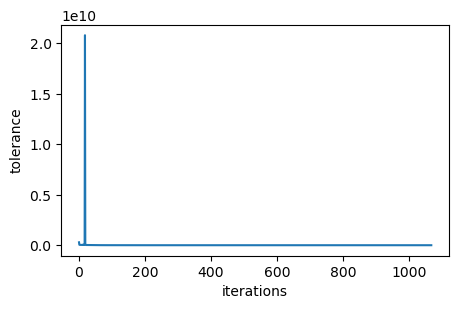

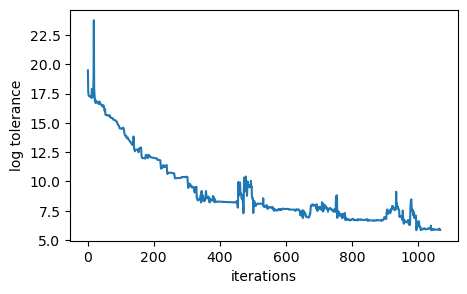

--> time = 0.98  min |  58.63 seconds
-> CGM converged?   True
-> Fit correctly?   False
Building full visibility model...
F2D model in 1.16 minutes.


In [10]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 1e5}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-6 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

# Plot

In [11]:
Plot_ = Plot(frank2d, geom)

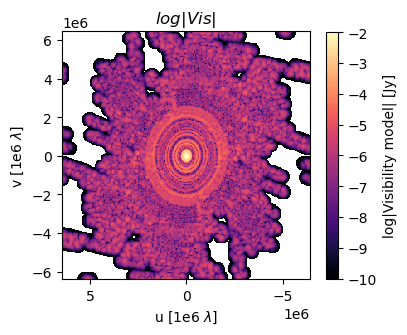

In [12]:
Plot_.visibility(fig_size = 4)

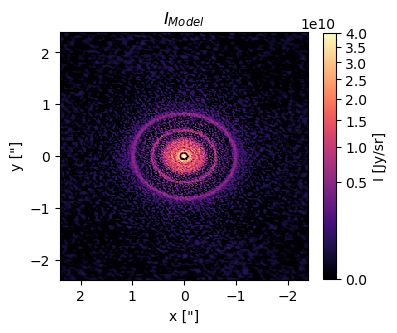

In [13]:
Plot_.intensity(fig_size = 4)

In [14]:
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']

In [15]:
uv_table = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

Performing 1D Frank fit...


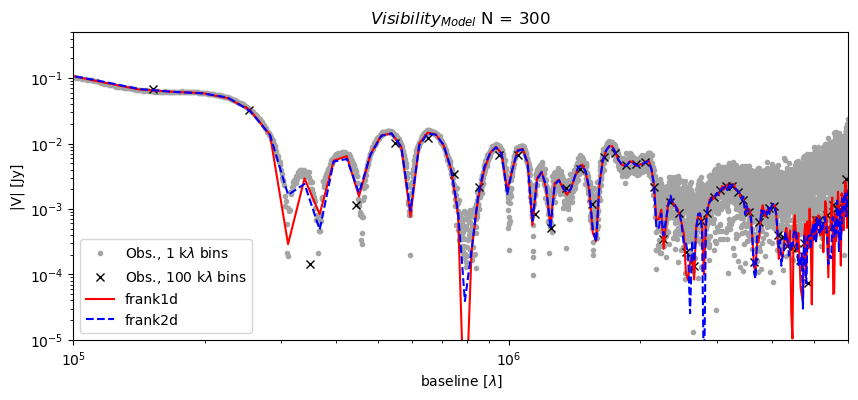

In [16]:
Plot_.visibility_profile(input = uv_table, weighted = True, frank1d = True)

In [17]:
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'
fits_file = dir + disk

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Performing 1D Frank fit...


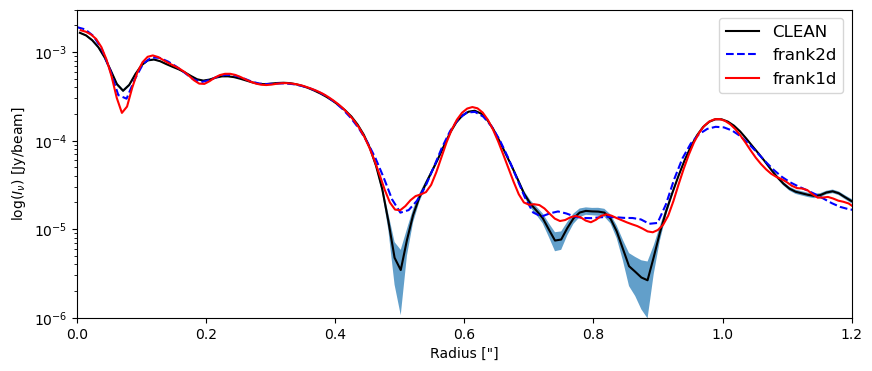

In [18]:
Plot_.intensity_profile(clean = True, fits_file = fits_file)

## Comparing CLEAN image

In [19]:
import matplotlib.colors as colors

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.ndimage import shift as ndshift

### CLEAN

In [20]:
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'

fits_name = dir + disk
fits_image = fits.open(fits_name)

In [21]:
header = fits_image[0].header

In [22]:
w = WCS(header).celestial
img_clean = np.squeeze(fits_image[0].data)

In [23]:
data = img_clean

In [24]:
dX_as, dY_as = dra, ddec

In [25]:
# --- inputs assumed: header, w (astropy WCS), img_clean, dX_as, dY_as,
#                     frank2d, rad_to_arcsec, np, u, SkyCoord, ndshift ---

hdr  = header.copy()
data = img_clean

# --- image center in pixel coordinates ---
ny, nx = data.shape
xc, yc = (nx - 1) / 2.0, (ny - 1) / 2.0

# --- sky coord at current image center (pixel -> world) ---
ra_c, dec_c = w.pixel_to_world_values(xc, yc)
center_sky = SkyCoord(ra_c * u.deg, dec_c * u.deg)

# --- sky coord that SHOULD land at the center after applying the offset ---
target_sky = center_sky.spherical_offsets_by(dX_as * u.arcsec, dY_as * u.arcsec)

# --- where does that target currently fall? (world -> pixel) ---
x1, y1 = w.world_to_pixel(target_sky)

# --- required subpixel shift to bring target to the matrix center ---
dx_pix = xc - x1
dy_pix = yc - y1

# --- shift the image (cubic interpolation) ---
data_shifted = ndshift(data, shift=(dy_pix, dx_pix), order=3, mode="constant", cval=np.nan)

# --- update WCS: shifting +Δpix in the array => decrease CRPIX by -Δpix ---
hdr["CRPIX1"] = hdr["CRPIX1"] + dx_pix
hdr["CRPIX2"] = hdr["CRPIX2"] + dy_pix

# --- pixel grid and world coords for the (shifted) image ---
x_max_arcsec = float(frank2d.x_grid.max() * rad_to_arcsec)  # desired half-size (arcsec)

Xpix, Ypix = np.meshgrid(np.arange(nx), np.arange(ny), indexing="xy")
RA_deg, DEC_deg = w.pixel_to_world_values(Xpix, Ypix)

# Offsets relative to CRVAL (includes cos(dec) factor automatically)
ref_sky = SkyCoord(hdr["CRVAL1"] * u.deg, hdr["CRVAL2"] * u.deg)
grid_sky = SkyCoord(RA_deg * u.deg, DEC_deg * u.deg)
dx, dy = ref_sky.spherical_offsets_to(grid_sky)  # angles on the tangent plane

X_as = dx.to(u.arcsec).value   # +X: East
Y_as = -dy.to(u.arcsec).value   # +Y: North

# --- build a ±R arcsec mask and compute a tight bounding box in pixels ---
R = x_max_arcsec +0.1
mask = (np.abs(X_as) <= R) & (np.abs(Y_as) <= R)
ys, xs = np.where(mask)

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

# --- coherent crops (data and coordinate grids) ---
data_clean = data_shifted[y0:y1, x0:x1]
X_clean = X_as[y0:y1, x0:x1] # arcsecs
Y_clean = Y_as[y0:y1, x0:x1]

In [26]:
frank2d.x_grid * rad_to_arcsec

array([[-2.4  , -2.384, -2.368, ...,  2.352,  2.368,  2.384],
       [-2.4  , -2.384, -2.368, ...,  2.352,  2.368,  2.384],
       [-2.4  , -2.384, -2.368, ...,  2.352,  2.368,  2.384],
       ...,
       [-2.4  , -2.384, -2.368, ...,  2.352,  2.368,  2.384],
       [-2.4  , -2.384, -2.368, ...,  2.352,  2.368,  2.384],
       [-2.4  , -2.384, -2.368, ...,  2.352,  2.368,  2.384]])

In [27]:
X_clean


array([[ 2.484,  2.481,  2.478, ..., -2.478, -2.481, -2.484],
       [ 2.484,  2.481,  2.478, ..., -2.478, -2.481, -2.484],
       [ 2.484,  2.481,  2.478, ..., -2.478, -2.481, -2.484],
       ...,
       [ 2.484,  2.481,  2.478, ..., -2.478, -2.481, -2.484],
       [ 2.484,  2.481,  2.478, ..., -2.478, -2.481, -2.484],
       [ 2.484,  2.481,  2.478, ..., -2.478, -2.481, -2.484]])

In [28]:
clean_img = np.flipud(data_clean)

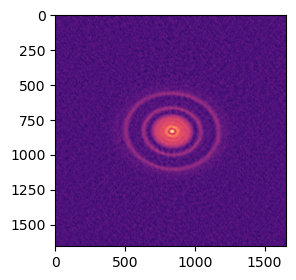

In [29]:
plt.figure(figsize=(3, 3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(clean_img, cmap ='magma', norm=norm)
plt.show()

In [30]:
data_clean = clean_img

### Frank2D

In [31]:
x_arcsec, y_arcsec = frank2d.x*rad_to_arcsec, frank2d.y*rad_to_arcsec
extent_convention = [-x_arcsec[0], -x_arcsec[-1], -y_arcsec[-1], -y_arcsec[0]]
model = frank2d.intensity_model

In [32]:
# let's do a phase shift first.
u_ = frank2d.u_grid
v_ = frank2d.v_grid
vis_ = frank2d.visibility_model
vis = geom.apply_phase_shift(-u_, -v_, vis_)
I_shifted = frank2d.transform(vis).real

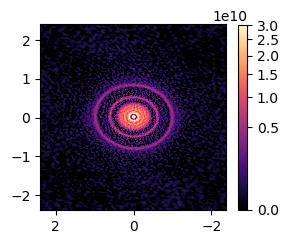

In [33]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45, vmin=0, vmax=3e10)
plt.imshow(I_shifted, cmap='magma',norm=norm, extent = extent_convention)
plt.colorbar(shrink = 0.8)

In [34]:
X_frank2d = -frank2d.x_grid*rad_to_arcsec
Y_frank2d = -frank2d.y_grid*rad_to_arcsec
M_frank2d = I_shifted

#### Turn into the same grid as CLEAN

In [35]:
X = X_clean
Y = Y_clean
M = data_clean

x_ = X[0, :]
y_ = Y[:, 0]

In [36]:
Xs = X_frank2d
Ys = Y_frank2d
Ms = M_frank2d

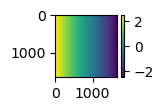

In [37]:
plt.figure(figsize=(1,1))
plt.imshow(X)
plt.colorbar(shrink = 0.8)

In [38]:
import astropy.units as u
from astropy.convolution import convolve_fft, Gaussian2DKernel
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator

# interpolate model CLEAN to the grid of Frank2D

# Method 1
pts_src   = np.c_[Y.ravel(order='C'), X.ravel(order='C')]               # grid clean
vals_src  = M.ravel(order='C')                                          # clean values
pts_tgt   = np.c_[Ys.ravel(order='C'), Xs.ravel(order='C')]             # grid f2d

model_1 = griddata(
    pts_src, vals_src, pts_tgt, method='linear', fill_value=np.nan
).reshape(Ms.shape)

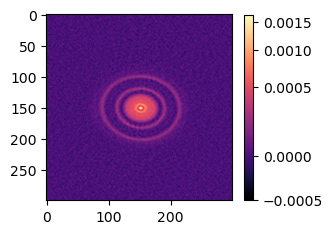

In [39]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(model_1, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [40]:
# Method 2
interp = RegularGridInterpolator(
    (y_, x_), M,
    method="linear", bounds_error=False, fill_value=np.nan
)
pts = np.stack([Ys.ravel(order="C"), Xs.ravel(order="C")], axis=-1)
model_2 = interp(pts).reshape(Ms.shape)

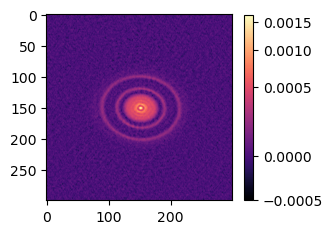

In [41]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(model_2, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [42]:
model_1.shape

(300, 300)

In [43]:
model_2.shape

(300, 300)

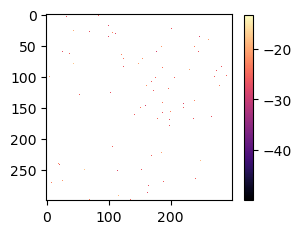

In [44]:
#difference
dif = model_1 - model_2
plt.figure(figsize=(3,3))
#norm = colors.PowerNorm(gamma=0.45)
plt.imshow(np.log(dif), cmap='magma')#, norm=norm)
plt.colorbar(shrink =0.8)

In [45]:
model = model_1

In [46]:
frank_model = M_frank2d

#### convolution with the CLEAN with the restoring beam (to match resolution)

In [47]:
# Beam parameters (major/minor FWHM in degrees and position angle)
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bpa_deg  = float(header.get("BPA", 0.0))

# Projected pixel scales (deg/pix) of the cutout (order (y, x))
dy_deg_pix, dx_deg_pix = proj_plane_pixel_scales(w)[-2], proj_plane_pixel_scales(w)[-1]

# FWHM (arcsec) -> pixels along image axes
bmaj_as = (bmaj_deg * u.deg).to(u.arcsec).value
bmin_as = (bmin_deg * u.deg).to(u.arcsec).value
fwhm_x_pix = bmaj_as / (abs(dx_deg_pix) * 3600.0)   # major axis in pixels along +x if BPA~0
fwhm_y_pix = bmin_as / (abs(dy_deg_pix) * 3600.0)   # minor axis in pixels along +y if BPA~0

# FWHM -> sigma (in pixels)
fwhm_to_sigma = 1.0 / (2.0*np.sqrt(2.0*np.log(2.0)))
sigma_x = fwhm_x_pix * fwhm_to_sigma
sigma_y = fwhm_y_pix * fwhm_to_sigma

# Kernel angle: Gaussian2DKernel expects radians, CCW from image +X;
# BPA is measured from North through East -> image angle = 90 - BPA
theta = np.deg2rad(90.0 - bpa_deg)

# Elliptical Gaussian beam kernel
gk = Gaussian2DKernel(x_stddev=sigma_x, y_stddev=sigma_y, theta=theta, mode='oversample', factor=5)
kernel = gk.array / np.sum(gk.array)  # ensure it sums to 1

# Convolution (preserves units of Jy/sr)
convoluted_model = convolve_fft(frank_model, kernel, allow_huge=True, normalize_kernel=True)

# 3) Convert Jy/sr -> Jy/beam
# Gaussian beam solid angle: omega = 2pi sigma_maj sigma_min, with sigma in radians (note: sigma in rad, not in pixels)
bmaj_rad = (bmaj_deg * u.deg).to(u.rad).value
bmin_rad = (bmin_deg * u.deg).to(u.rad).value
sigma_maj = bmaj_rad * fwhm_to_sigma
sigma_min = bmin_rad * fwhm_to_sigma
Omega_beam_sr = 2.0 * np.pi * sigma_maj * sigma_min  # [sr]

model_conv_Jy_per_beam = convoluted_model * Omega_beam_sr

# 4) COMPARE / RESIDUAL (both in Jy/beam)
residual = model - model_conv_Jy_per_beam

In [48]:
bmaj_as = np.radians(fits_image[0].header['bmaj']) * 206265  # arcsec
bmin_as = np.radians(fits_image[0].header['bmin']) * 206265  # arcsec
str_to_beam = np.pi/(4*np.log(2.)) * bmaj_as * bmin_as* (1/rad_to_arcsec)**2

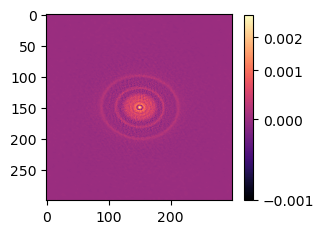

In [49]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(frank_model * Omega_beam_sr , cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

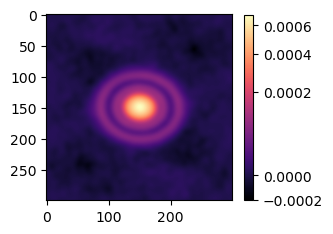

In [50]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(model_conv_Jy_per_beam, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)

In [51]:
from astropy.stats import sigma_clip

# --- Useful stats ---
# residuals already computed: 'residual' (Jy/beam), same shape as data_c
finite = np.isfinite(residual)
res_vals = residual[finite]

# Robust clipping: 3-sigma, up to 5 iterations, centered on the median
res_clip = sigma_clip(res_vals, sigma=3.0, maxiters=5, cenfunc="median", stdfunc="std")

# RMS of the clipped residual
std = np.nanstd(res_clip)

print(f"RMS residual (clipped): {std:.4g} Jy/beam")
print(f"Residual peak:          {np.nanmax(residual):.4g} Jy/beam")
print(f"Residual min:           {np.nanmin(residual):.4g} Jy/beam")

RMS residual (clipped): 1.894e-05 Jy/beam
Residual peak:          0.0009597 Jy/beam
Residual min:           -0.0003666 Jy/beam


In [52]:
np.max(model_conv_Jy_per_beam)

0.0006821881213146183

In [53]:
np.max(model)

0.0016374052887059326

In [54]:
np.max(residual)/std

50.68411101807106

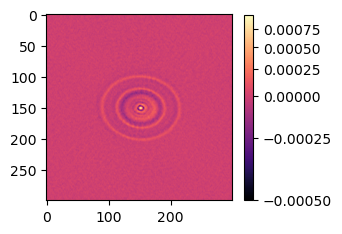

In [55]:
plt.figure(figsize=(3,3))
norm = colors.PowerNorm(gamma=0.45)
plt.imshow(residual, cmap='magma', norm=norm)
plt.colorbar(shrink =0.8)